<a href="https://colab.research.google.com/github/sharyali05/kyrgyz-youtube-visual-audit/blob/main/05_cnn_embedding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05 — CNN Embedding and UMAP Visualization
### Visual Semiotics and Language Ideologies in Kyrgyz Digital Media

This notebook maps YouTube thumbnails into a 2D visual space using:
1. **MobileNetV2** — a pretrained CNN that extracts a 1280-dimensional feature vector per thumbnail
2. **UMAP** — reduces those vectors to 2D for visualization

This allows us to ask: do Russian and Kyrgyz thumbnails occupy **distinct regions** in visual space, or do they overlap substantially?

**Input:** `data/visual_features.csv` (generated by `colab_thumbnail_analysis.ipynb`)

**Output:**
- `data/visual_features_umap.csv` — original features + 2D UMAP coordinates
- `results/figures/fig9_umap_embedding` — scatter plot colored by language group
- `results/figures/fig10_umap_luminance` — scatter plot colored by luminance
- `results/figures/fig11_umap_saturation` — scatter plot colored by saturation
- `results/figures/fig12_umap_text` — scatter plot colored by text overlay score

---
## Cell 1 — Mount Drive and install dependencies

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q umap-learn
print('Done.')

Mounted at /content/drive
Done.


## Cell 2 — Set paths and load data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE        = Path('/content/drive/MyDrive/kyrgyz-audit')
FIGURES_DIR = BASE / 'results/figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Load visual features ──────────────────────────────────────────────────────
# Use visual_features_with_text.csv if available, otherwise visual_features.csv
features_path = BASE / 'data/visual_features_with_text.csv'
if not features_path.exists():
    features_path = BASE / 'data/visual_features.csv'
    print('Using visual_features.csv (no text features)')
else:
    print('Using visual_features_with_text.csv')

df = pd.read_csv(features_path)
df_valid = df[
    (df['thumbnail_found'] == 1) &
    (df['language'].isin(['russian', 'kyrgyz', 'english']))
].copy().reset_index(drop=True)

print(f'Total videos with thumbnails: {len(df_valid):,}')
print(df_valid['language'].value_counts().to_string())

Using visual_features_with_text.csv
Total videos with thumbnails: 532
language
kyrgyz     182
russian    177
english    173


## Cell 3 — Load MobileNetV2

In [3]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Load pretrained MobileNetV2 — no top classification layer, global average pooling
# This gives a 1280-dim feature vector per image
model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')
print(f'MobileNetV2 loaded.')
print(f'Input shape:  (None, 224, 224, 3)')
print(f'Output shape: {model.output_shape}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded.
Input shape:  (None, 224, 224, 3)
Output shape: (None, 1280)


## Cell 4 — Fetch thumbnails

In [4]:
import requests
from PIL import Image
from io import BytesIO
from tqdm.notebook import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed


def fetch_and_preprocess(video_id, size=(224, 224)):
    """Fetch thumbnail and resize to MobileNetV2 input size."""
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
    for quality in ['hqdefault', 'mqdefault', 'default']:
        url = f"https://img.youtube.com/vi/{video_id}/{quality}.jpg"
        try:
            r = requests.get(url, timeout=5, headers=headers)
            if r.status_code == 200:
                img = Image.open(BytesIO(r.content)).convert('RGB')
                arr = np.array(img)
                if arr.shape[0] >= 90:
                    return np.array(img.resize(size))
        except Exception:
            continue
    return None


def fetch_row(item):
    idx, row = item
    img = fetch_and_preprocess(row['video_id'])
    return idx, img


print('Fetching thumbnails...')
images      = []
valid_indices = []

with ThreadPoolExecutor(max_workers=20) as executor:
    futures = {
        executor.submit(fetch_row, item): item
        for item in df_valid.iterrows()
    }
    for future in tqdm(as_completed(futures),
                       total=len(futures), desc='Fetching thumbnails'):
        idx, img = future.result()
        if img is not None:
            images.append(img)
            valid_indices.append(idx)

df_embed = df_valid.loc[valid_indices].copy().reset_index(drop=True)
print(f'\nSuccessfully fetched: {len(images):,} thumbnails')
print(df_embed['language'].value_counts().to_string())

Fetching thumbnails...


Fetching thumbnails:   0%|          | 0/532 [00:00<?, ?it/s]


Successfully fetched: 532 thumbnails
language
kyrgyz     182
russian    177
english    173


## Cell 5 — Extract CNN embeddings

In [5]:
print('Preprocessing images...')
img_array       = np.array(images, dtype=np.float32)
img_preprocessed = preprocess_input(img_array.copy())

print(f'Image array shape: {img_array.shape}')
print('Extracting CNN embeddings (batches of 32)...')

batch_size = 32
embeddings = []

for i in tqdm(range(0, len(img_preprocessed), batch_size), desc='Embedding'):
    batch = img_preprocessed[i:i+batch_size]
    emb   = model.predict(batch, verbose=0)
    embeddings.append(emb)

embeddings = np.vstack(embeddings)
print(f'\nEmbeddings shape: {embeddings.shape}')
print('Each thumbnail is now a 1280-dimensional feature vector.')

Preprocessing images...
Image array shape: (532, 224, 224, 3)
Extracting CNN embeddings (batches of 32)...


Embedding:   0%|          | 0/17 [00:00<?, ?it/s]


Embeddings shape: (532, 1280)
Each thumbnail is now a 1280-dimensional feature vector.


## Cell 6 — Dimensionality reduction with UMAP

In [6]:
import umap

print('Running UMAP (this takes ~2-3 minutes)...')
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,   # larger = more global structure preserved
    min_dist=0.1,     # smaller = tighter clusters
    random_state=42,
    metric='cosine'   # cosine distance works well for CNN embeddings
)
embedding_2d = reducer.fit_transform(embeddings)
print('UMAP complete.')

# Add coordinates to dataframe
df_embed['umap_x'] = embedding_2d[:, 0]
df_embed['umap_y'] = embedding_2d[:, 1]

# Save enriched dataframe
df_embed.to_csv(BASE / 'data/visual_features_umap.csv', index=False)
print(f'Saved visual_features_umap.csv')

Running UMAP (this takes ~2-3 minutes)...
UMAP complete.
Saved visual_features_umap.csv


## Cell 7 — Global style settings

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

PALETTE = {
    'russian': '#d95f02',
    'kyrgyz':  '#1b9e77',
    'english': '#7570b3',
}
LANG_LABELS = {
    'russian': 'Russian',
    'kyrgyz':  'Kyrgyz',
    'english': 'English',
}

plt.rcParams.update({
    'figure.dpi':      150,
    'savefig.dpi':     300,
    'savefig.bbox':    'tight',
    'font.family':     'sans-serif',
})

def save_fig(name):
    for ext in ['png', 'pdf']:
        plt.savefig(FIGURES_DIR / f'{name}.{ext}')
    print(f'Saved {name}.png and {name}.pdf')

print('Style settings applied.')

Style settings applied.


---
## Figure 9 — UMAP colored by language group
Do Russian and Kyrgyz thumbnails occupy distinct visual territories?

Saved fig9_umap_language.png and fig9_umap_language.pdf


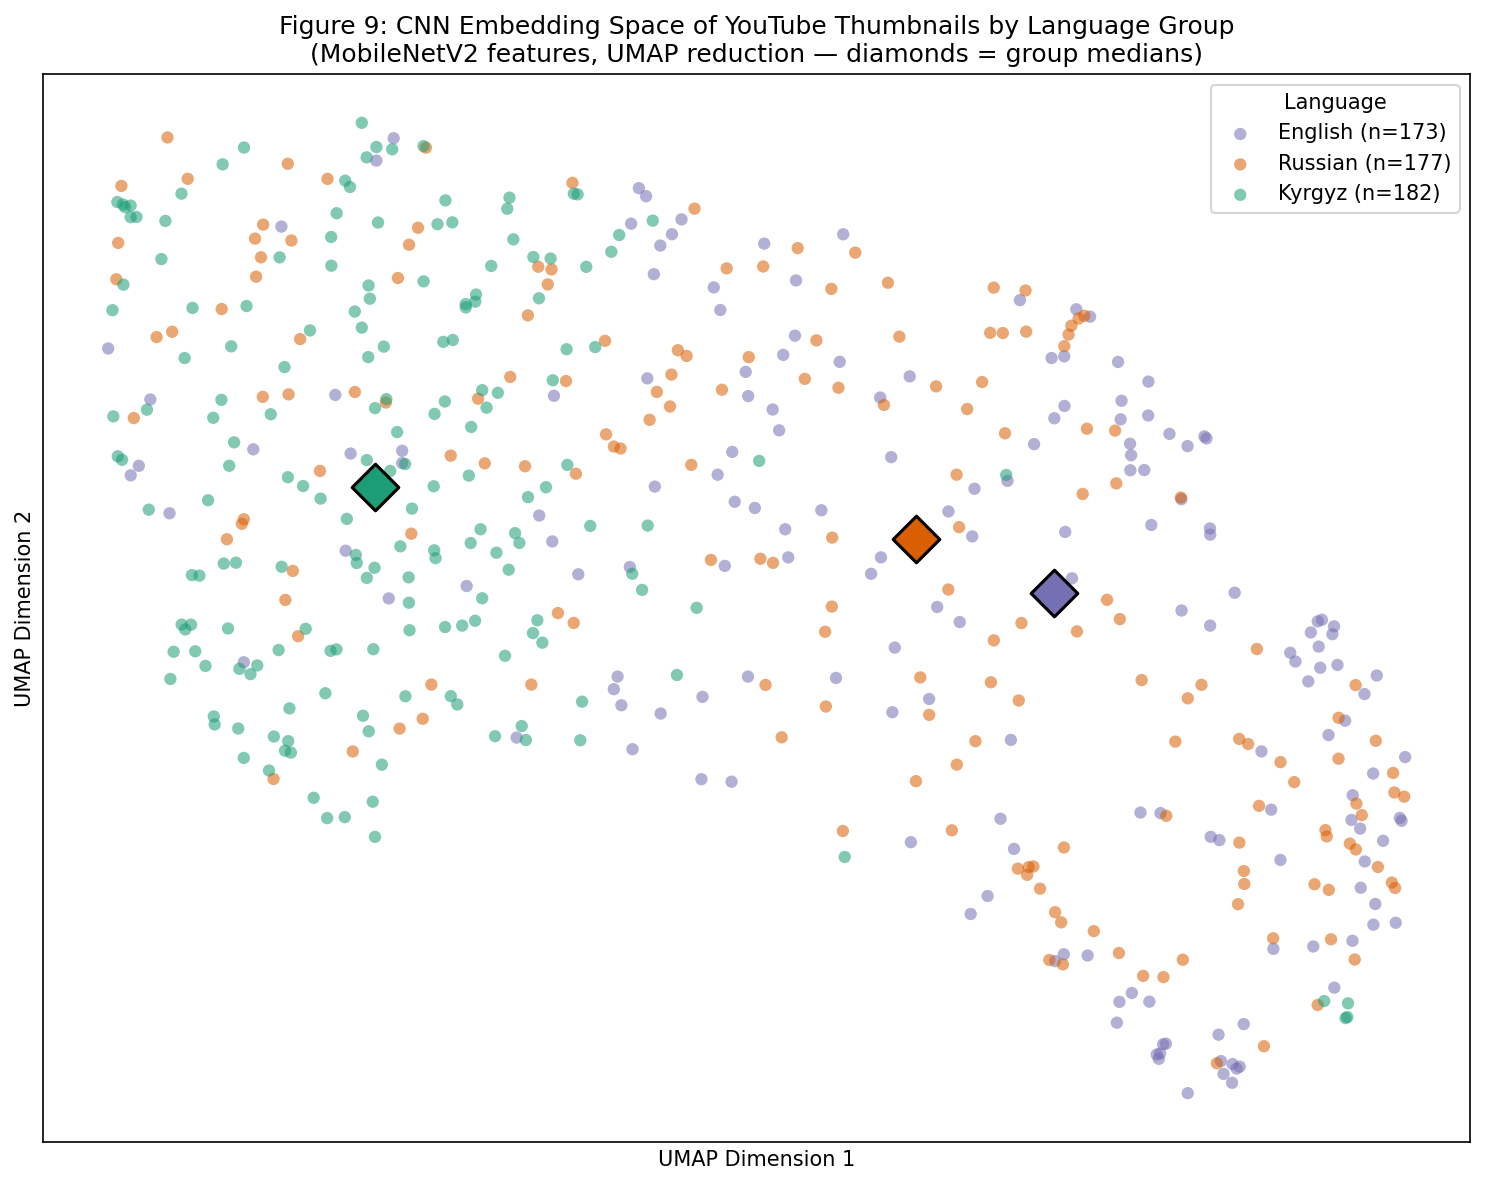

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))

for lang in ['english', 'russian', 'kyrgyz']:  # english first so others overlay
    subset = df_embed[df_embed['language'] == lang]
    ax.scatter(
        subset['umap_x'], subset['umap_y'],
        c=PALETTE[lang],
        label=f"{LANG_LABELS[lang]} (n={len(subset)})",
        alpha=0.55, s=35,
        edgecolors='none'
    )

# Add group centroids
for lang in ['russian', 'kyrgyz', 'english']:
    subset = df_embed[df_embed['language'] == lang]
    ax.scatter(
        subset['umap_x'].median(),
        subset['umap_y'].median(),
        c=PALETTE[lang],
        s=250, marker='D',
        edgecolors='black', linewidths=1.5,
        zorder=5
    )

ax.set_title(
    'Figure 9: CNN Embedding Space of YouTube Thumbnails by Language Group\n'
    '(MobileNetV2 features, UMAP reduction — diamonds = group medians)',
    fontsize=12
)
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.legend(title='Language', fontsize=10)
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
save_fig('fig9_umap_language')
plt.show()

---
## Figure 10 — UMAP colored by luminance
Does the brightness gradient in the data map onto a spatial gradient in the embedding?

Saved fig10_umap_luminance.png and fig10_umap_luminance.pdf


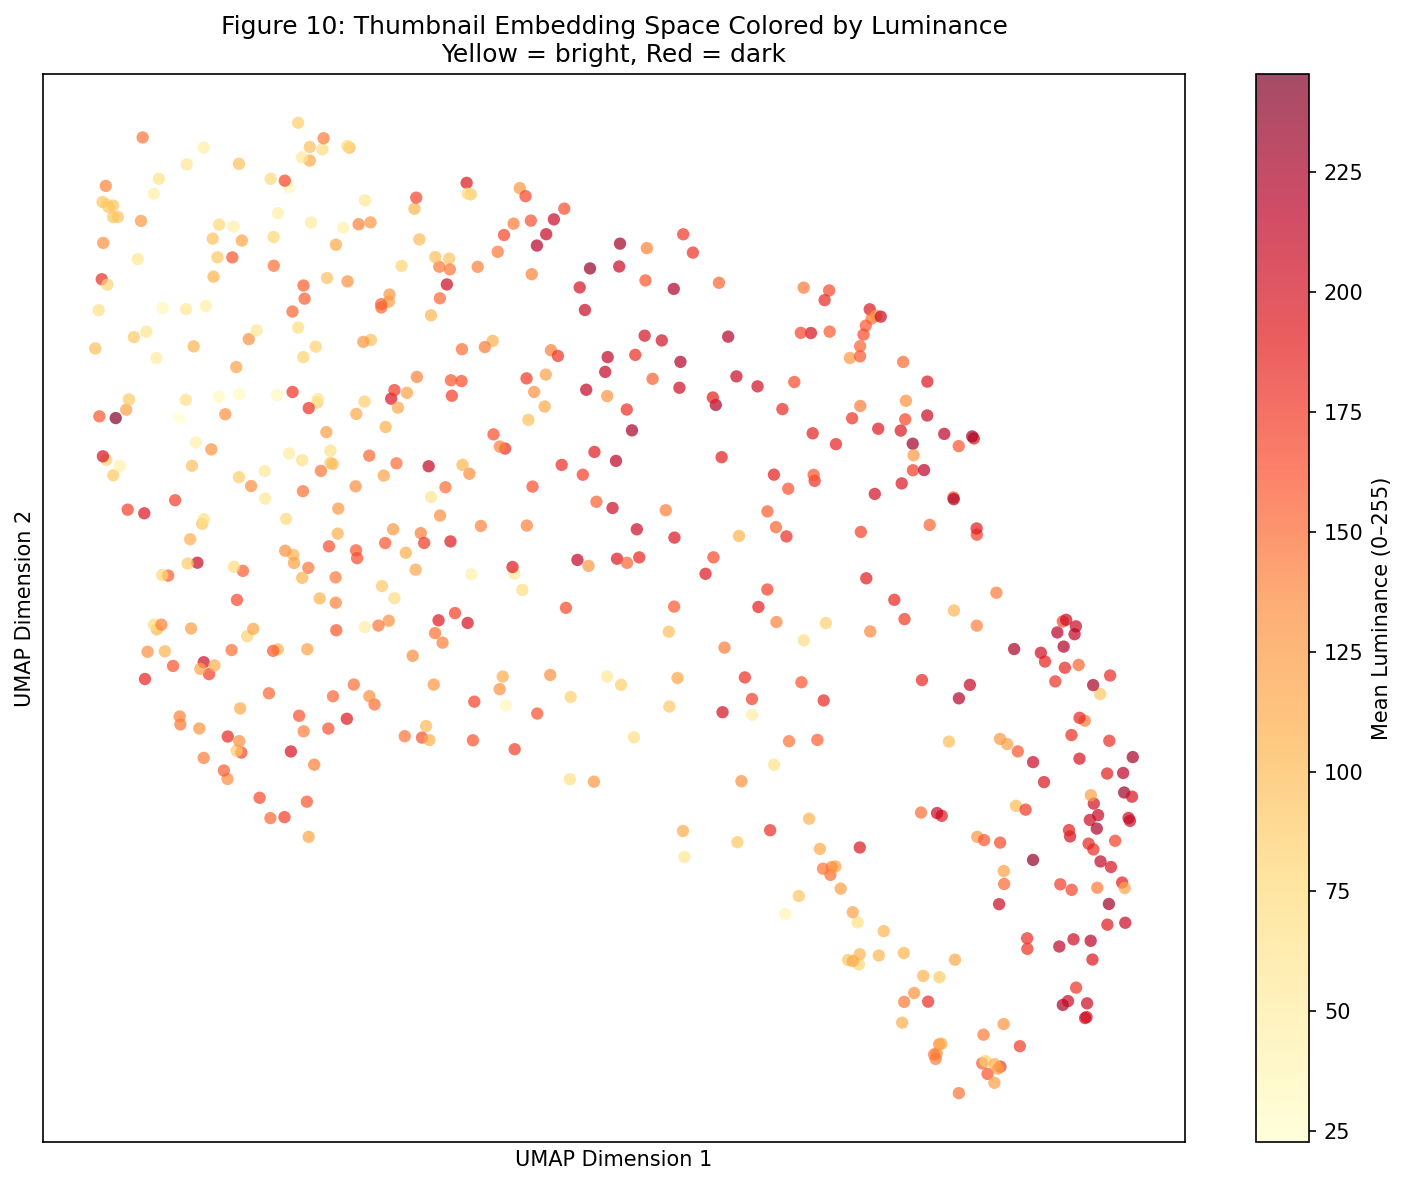

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(
    df_embed['umap_x'], df_embed['umap_y'],
    c=df_embed['mean_luminance'],
    cmap='YlOrRd',
    alpha=0.7, s=35,
    edgecolors='none'
)
plt.colorbar(sc, ax=ax, label='Mean Luminance (0–255)')

ax.set_title(
    'Figure 10: Thumbnail Embedding Space Colored by Luminance\n'
    'Yellow = bright, Red = dark',
    fontsize=12
)
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
save_fig('fig10_umap_luminance')
plt.show()

---
## Figure 11 — UMAP colored by saturation

Saved fig11_umap_saturation.png and fig11_umap_saturation.pdf


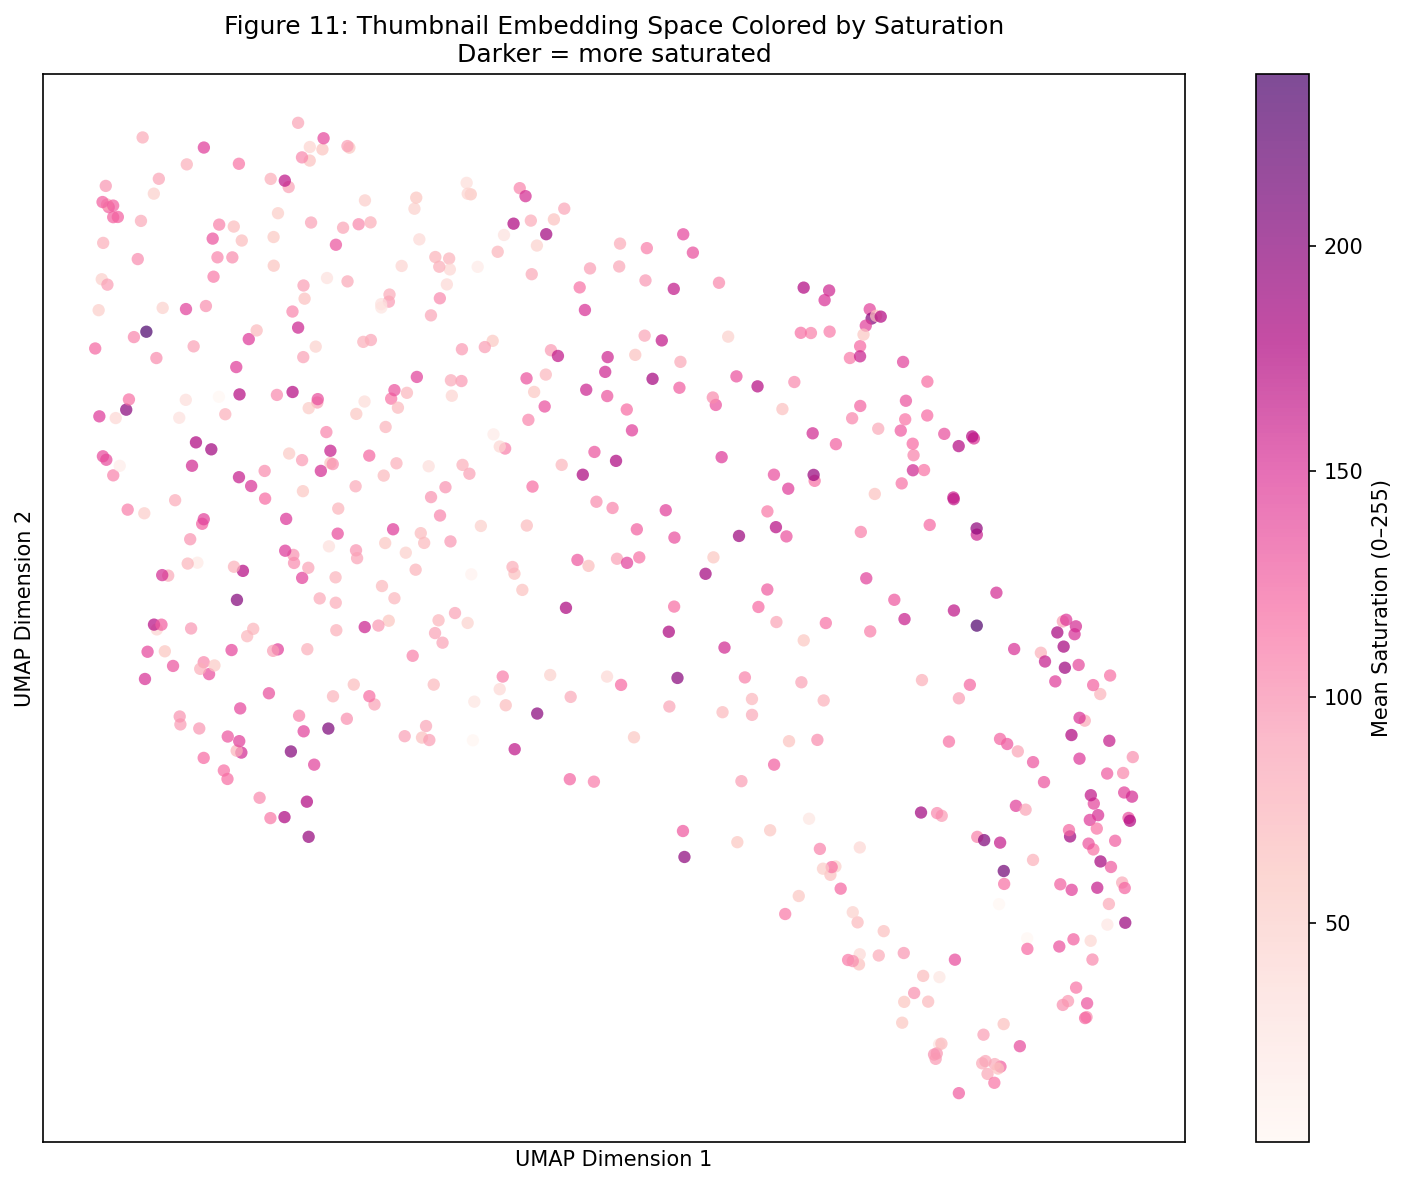

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(
    df_embed['umap_x'], df_embed['umap_y'],
    c=df_embed['mean_saturation'],
    cmap='RdPu',
    alpha=0.7, s=35,
    edgecolors='none'
)
plt.colorbar(sc, ax=ax, label='Mean Saturation (0–255)')

ax.set_title(
    'Figure 11: Thumbnail Embedding Space Colored by Saturation\n'
    'Darker = more saturated',
    fontsize=12
)
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
save_fig('fig11_umap_saturation')
plt.show()

---
## Figure 12 — UMAP colored by text overlay score
Only available if visual_features_with_text.csv was used.

Saved fig12_umap_text.png and fig12_umap_text.pdf


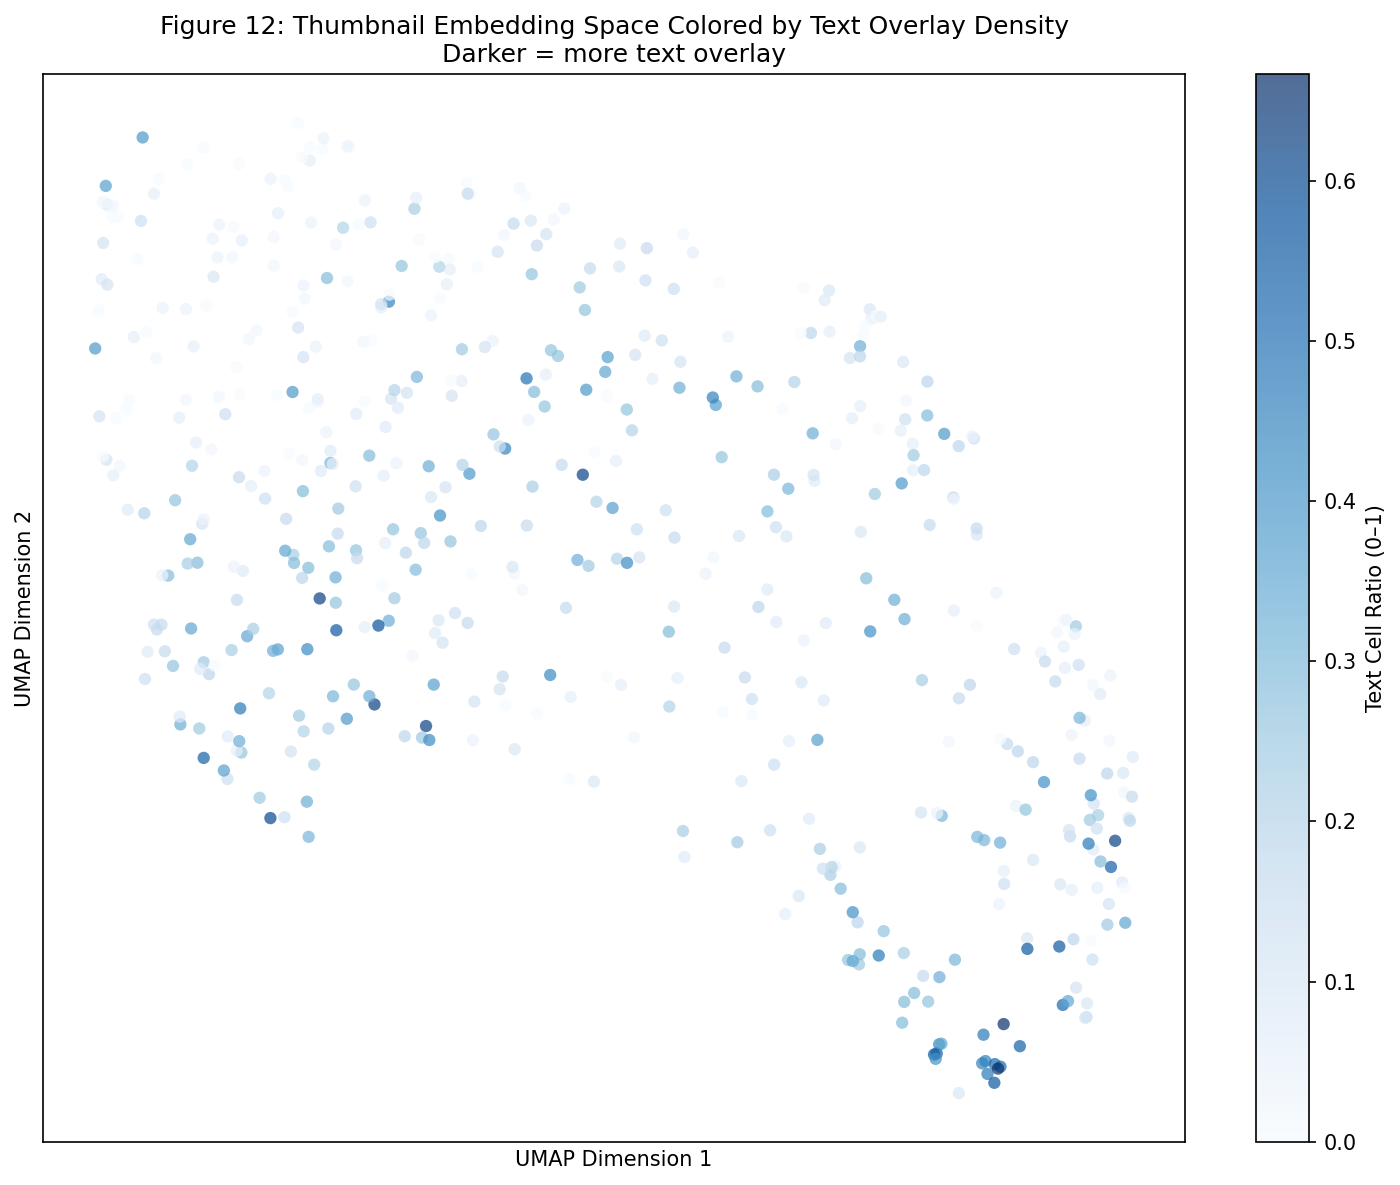

In [11]:
if 'text_cell_ratio' in df_embed.columns:
    fig, ax = plt.subplots(figsize=(10, 8))

    sc = ax.scatter(
        df_embed['umap_x'], df_embed['umap_y'],
        c=df_embed['text_cell_ratio'],
        cmap='Blues',
        alpha=0.7, s=35,
        edgecolors='none'
    )
    plt.colorbar(sc, ax=ax, label='Text Cell Ratio (0–1)')

    ax.set_title(
        'Figure 12: Thumbnail Embedding Space Colored by Text Overlay Density\n'
        'Darker = more text overlay',
        fontsize=12
    )
    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout()
    save_fig('fig12_umap_text')
    plt.show()
else:
    print('Text features not available — skipping Figure 12.')
    print('Re-run with visual_features_with_text.csv to include this figure.')

---
## Cell 8 — Quantify cluster separation
Measures how well the language groups separate in UMAP space using silhouette score.
Score ranges from -1 (overlapping) to +1 (perfectly separated).

In [12]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
labels = le.fit_transform(df_embed['language'])

# Silhouette score on raw embeddings
sil_high = silhouette_score(embeddings, labels, metric='cosine')

# Silhouette score on 2D UMAP coordinates
sil_2d = silhouette_score(
    df_embed[['umap_x', 'umap_y']].values, labels
)

print('=' * 50)
print('CLUSTER SEPARATION ANALYSIS')
print('=' * 50)
print(f'Silhouette score (1280-dim embeddings): {sil_high:.4f}')
print(f'Silhouette score (2D UMAP):             {sil_2d:.4f}')
print()
print('Interpretation:')
print('  > 0.5  = well-separated clusters')
print('  0.2–0.5 = moderate separation')
print('  < 0.2  = overlapping clusters')
print()

# Per-language centroid distances
print('Centroid positions in UMAP space:')
for lang in ['russian', 'kyrgyz', 'english']:
    subset = df_embed[df_embed['language'] == lang]
    cx = subset['umap_x'].mean()
    cy = subset['umap_y'].mean()
    print(f'  {lang:<12}  x={cx:.2f}, y={cy:.2f}')

# Euclidean distance between Russian and Kyrgyz centroids
rus = df_embed[df_embed['language'] == 'russian'][['umap_x','umap_y']].mean()
kyr = df_embed[df_embed['language'] == 'kyrgyz'][['umap_x','umap_y']].mean()
dist = np.sqrt((rus['umap_x']-kyr['umap_x'])**2 + (rus['umap_y']-kyr['umap_y'])**2)
print(f'\nEuclidean distance (Russian vs Kyrgyz centroids): {dist:.3f}')

CLUSTER SEPARATION ANALYSIS
Silhouette score (1280-dim embeddings): 0.0204
Silhouette score (2D UMAP):             0.0776

Interpretation:
  > 0.5  = well-separated clusters
  0.2–0.5 = moderate separation
  < 0.2  = overlapping clusters

Centroid positions in UMAP space:
  russian       x=0.18, y=1.27
  kyrgyz        x=-2.53, y=1.64
  english       x=0.97, y=1.01

Euclidean distance (Russian vs Kyrgyz centroids): 2.730


## UMAP and CNN Embedding Analysis — Interpretation

### Cluster separation results
The silhouette scores indicate substantial overlap between language groups
in the CNN embedding space:

- **1280-dim embeddings: 0.020** — near-zero separation in high-dimensional space
- **2D UMAP: 0.078** — slight but still low separation after dimensionality reduction

Both scores fall well below the 0.2 threshold for meaningful cluster separation,
indicating that Russian, Kyrgyz, and English thumbnails do **not** occupy
clearly distinct territories in visual space as perceived by MobileNetV2.

### What the centroid distances tell us
Despite the overlap, the centroid positions reveal a meaningful spatial pattern:

| Language | UMAP x | UMAP y |
|---|---|---|
| Russian  | 0.18   | 1.27   |
| Kyrgyz   | -2.53  | 1.64   |
| English  | 0.97   | 1.01   |

The Euclidean distance between Russian and Kyrgyz centroids (2.730) is
substantially larger than the Russian-English distance, and the Kyrgyz
centroid sits clearly to the left of both Russian and English. This means
that while individual thumbnails from all three groups intermingle in the
embedding space, **the average visual character of Kyrgyz content pulls in
a different direction** than Russian and English content — which cluster
much closer together.

### Reconciling overlap with statistical differences
At first glance, near-zero silhouette scores might appear to contradict the
significant luminance finding from the statistical analysis. These results
are in fact complementary and tell a more nuanced story together:

The statistical analysis found that Russian thumbnails are significantly
**brighter** than Kyrgyz ones on average (r = 0.36). But the CNN embedding
analysis shows that this brightness difference does not translate into
wholesale visual separation — the two groups share much of the same visual
territory. This means the visual difference between Russian and Kyrgyz
content is **real but partial**: it is concentrated in specific measurable
dimensions (luminance, text density) rather than reflecting a total
difference in visual character.

This is consistent with the theoretical argument that Kyrgyz content
represents a **distinct register** rather than simply inferior content.
If Kyrgyz thumbnails were simply lower-quality versions of Russian ones,
we might expect them to cluster at one end of a quality gradient. Instead,
they occupy a different spatial position in the embedding — pulled to the
left in UMAP space — suggesting they are visually different in kind, not
just in degree.

### The luminance gradient (Figure 10)
The visible gradient from darker (upper-left) to brighter (lower-right)
in the luminance-colored UMAP provides convergent visual evidence for the
statistical finding. The fact that this gradient aligns spatially with the
Kyrgyz-left / Russian-right centroid split confirms that luminance is one
of the structural axes organizing the visual landscape of this content.

### The text overlay pattern (Figure 12)
Text-heavy thumbnails cluster noticeably in the lower-right corner of the
UMAP — the same region where Russian and English centroids are located.
This spatially corroborates the text overlay finding: the commercial vlogger
aesthetic (bright, text-heavy) is concentrated in the Russian/English visual
territory, while the Kyrgyz centroid sits in a lower-text-density region.

### Limitations of this analysis
- MobileNetV2 was trained on ImageNet (everyday objects) and may not capture
  the most culturally relevant visual distinctions between these content types.
  A model fine-tuned on YouTube thumbnails might show stronger separation.
- UMAP is a non-linear, stochastic projection — the specific layout is one
  of many possible valid projections. The centroid distances should be
  interpreted as indicative rather than definitive.
- The low silhouette score may partly reflect the heterogeneity within each
  language group (animation vs. live action, children's vs. adult content)
  rather than genuine similarity across groups.
- Future work could run this analysis separately for animated vs. live-action
  content to test whether subgenre accounts for some of the observed overlap.